# CME Futures: Feasibility Analysis

`config/setup.yaml` declares a cross-sectional futures strategy: which products
trade, how often positions change, what a round trip costs, and how the sample is
split for evaluation. This notebook reads that file and asks whether the data
supports what it declares. It fits nothing and forecasts nothing.

## Learning objectives

- Count the universe at every decision date against the breadth a two-sided book needs
- Recover a contract's tick from settlement prices and price a round trip with it
- Read the fraction of moves that clears cost off an exceedance curve, per horizon
- Measure how long the term-structure slope a carry strategy reads stays put

## Book reference

Chapter 6, Sections 6.2-6.6. Reads CME daily settlements via `load_cme_futures()`
and `config/setup.yaml`, the strategy declaration this notebook never writes.

In [1]:
"""CME Futures Case Study - Feasibility Analysis."""

import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.splitters import WalkForwardCV

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_cme_futures
from utils.cv_splits import generate_cv_splits, make_walk_forward_config
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "cme_futures"
START_DATE = "2011-01-01"
END_DATE = "2025-12-31"

## Configuration

Every knob below is read from `setup.yaml`. The holdout boundary matters most: Section
B computes on the development window alone, so nothing the holdout contains can shape a
design choice made here. Candidate horizons come from the declared labels.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
DECLARED_PRODUCTS = sorted(p for g in SETUP["universe"]["product_groups"].values() for p in g)
BREADTH_FLOOR = 2 * max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
SPREAD_TICKS = SETUP["costs"]["spread_ticks"]["liquid"]
LABELS = [PRIMARY_LABEL, *SETUP["labels"]["variants"]]
HORIZONS = sorted(int(re.search(r"(\d+)d$", name).group(1)) for name in LABELS)

print(f"Development {START_DATE} to {HOLDOUT_START} | sealed holdout to {HOLDOUT_END}")
print(f"{len(DECLARED_PRODUCTS)} products, floor {BREADTH_FLOOR} | horizons {HORIZONS} sessions")

Development 2011-01-01 to 2024-01-01 | sealed holdout to 2025-12-31
30 products, floor 20 | horizons [5, 21] sessions


## A. Orientation

CME futures give leveraged exposure across equity indices, rates, energy, metals,
currencies, agriculture and livestock through one order type and one clearing house.
A front-month position earns the spot move plus the roll yield the term structure
implies, so ranking products against each other trades a difference in carry as much
as a difference in direction. Three questions decide whether that is worth building
here: does the declared universe exist at every decision date and not just on
average, is a typical move large next to what it costs to capture, and does the
sample carry enough decision dates for a walk-forward evaluation that never reads
the holdout? Section C records which `setup.yaml` value each answer motivates.

## B. Universe and cost feasibility

### B.1 Load and verify the declared universe

The loader returns one row per product, tenor and session; `tenor == 0` is the front
month. Two price columns matter and are not interchangeable: `raw_close` is the
printed settlement, so it lies on the contract's price grid, while `adj_close` is
back-adjusted, so its differences are price moves rather than roll gaps.

In [4]:
futures = load_cme_futures(start_date=START_DATE, end_date=END_DATE)
front = (
    futures.filter(pl.col("tenor") == 0)
    .select(["product", "session_date", "raw_close", "adj_close"])
    .sort(["product", "session_date"])
)
research = front.filter(pl.col("session_date") < pl.lit(HOLDOUT_START).str.to_date())

missing = sorted(set(DECLARED_PRODUCTS) - set(research["product"].unique().to_list()))
assert not missing, f"declared in setup.yaml but absent from the data: {missing}"
print(
    f"{research['product'].n_unique()} products, {len(research):,} settlements, "
    f"{research['session_date'].min()} to {research['session_date'].max()}"
)

30 products, 98,116 settlements, 2011-01-03 to 2023-12-29

### B.2 Breadth at every decision date

One count of the universe hides the question a cross-sectional strategy has to answer,
which is whether the products are there *when a decision is made*. Products list at
different dates, so early decision dates can carry a fraction of the universe while the
average looks healthy. The line is the position count the widest sweep holds, both legs.

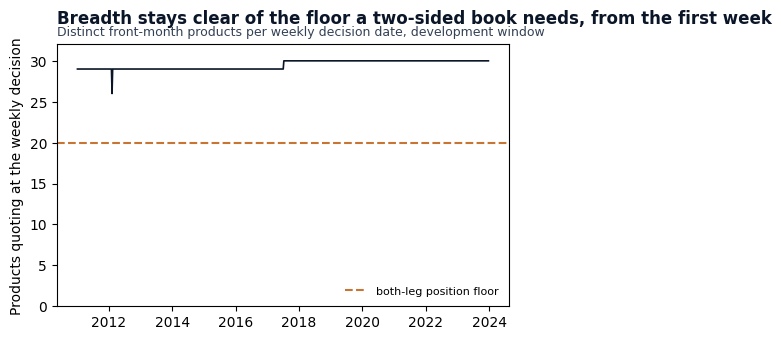

In [5]:
breadth = (
    research.with_columns(pl.col("session_date").dt.truncate("1w").alias("decision_week"))
    .group_by("decision_week")
    .agg(pl.col("product").n_unique().alias("n_products"))
    .sort("decision_week")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(breadth["decision_week"], breadth["n_products"], color=COLORS["blue"], linewidth=1.2)
ax.axhline(BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="both-leg position floor")
ax.set_ylim(0, len(DECLARED_PRODUCTS) + 2)
ax.set_ylabel("Products quoting at the weekly decision")
ax.legend(frameon=False, fontsize=8, loc="lower right")
add_message_title(
    ax,
    "Breadth stays clear of the floor a two-sided book needs, from the first week",
    subtitle="Distinct front-month products per weekly decision date, development window",
)
plt.show()

### B.3 What a round trip costs, and what a move is worth

`setup.yaml::costs` prices a trade as a commission plus a spread quoted in ticks. The
tick is a contract specification and it is recoverable: the smallest non-zero change in
a settlement price is the grid the contract trades on. Crossing a one-tick spread costs
half a tick per leg, so a round trip costs one tick, and dividing by the typical price
puts every product on a basis-point scale. The commission needs a notional to convert.

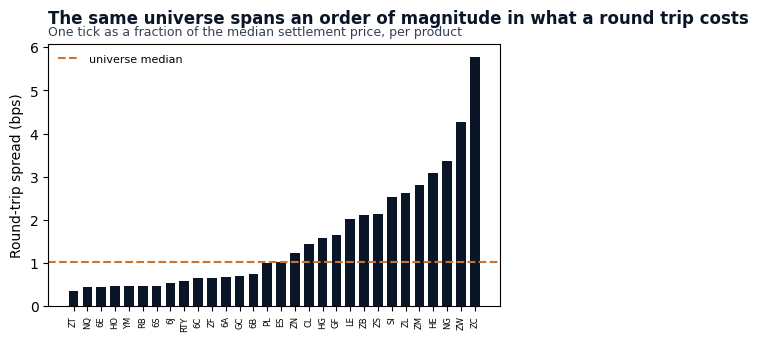

In [6]:
cost = (
    research.with_columns(pl.col("raw_close").diff().abs().over("product").alias("increment"))
    .filter(pl.col("increment") > 0)
    .group_by("product")
    .agg(pl.col("increment").min().alias("tick"), pl.col("raw_close").median().alias("price"))
    .with_columns((SPREAD_TICKS * pl.col("tick") / pl.col("price") * 1e4).alias("round_trip_bps"))
    .sort("round_trip_bps")
)
COST_BPS = float(cost["round_trip_bps"].median())
COST_FRACTION = COST_BPS / 10_000

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.bar(cost["product"], cost["round_trip_bps"], color=COLORS["blue"], width=0.7)
ax.axhline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="universe median")
ax.set_ylabel("Round-trip spread (bps)")
ax.tick_params(axis="x", labelsize=6, rotation=90)
ax.legend(frameon=False, fontsize=8)
add_message_title(
    ax,
    "The same universe spans an order of magnitude in what a round trip costs",
    subtitle="One tick as a fraction of the median settlement price, per product",
)
plt.show()

Against that cost sits the move a position is trying to capture. The curves below give
the fraction of absolute returns at or above each magnitude, per candidate horizon on
one logarithmic axis. Reading up from the cost line gives the share of moves large
enough to pay for the trade that captured them.

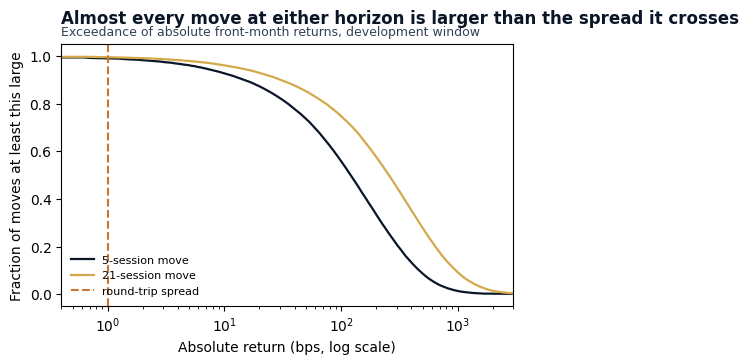

In [7]:
returns = research.with_columns(
    pl.col("adj_close").pct_change(h).abs().over("product").alias(f"h{h}") for h in HORIZONS
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, color in zip(HORIZONS, (COLORS["blue"], COLORS["amber"]), strict=True):
    magnitude, fraction = exceedance_curve(returns[f"h{h}"].drop_nulls().to_numpy())
    ax.plot(magnitude * 10_000, fraction, color=color, lw=1.6, label=f"{h}-session move")
ax.axvline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="round-trip spread")
ax.set_xscale("log")
ax.set_xlim(0.4, 3_000)
ax.set_xlabel("Absolute return (bps, log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Almost every move at either horizon is larger than the spread it crosses",
    subtitle="Exceedance of absolute front-month returns, development window",
)
plt.show()

### B.4 How long the carrier stays put

Rebalancing weekly is only worth the turnover if what the data says at one decision
date still says something at the next. This strategy reads carry, visible in the raw
prices as the slope between the front contract and the one behind it: a positive slope
means a long position rolls into a more expensive contract and gives back part of the
spot move. How long that reading lasts is an autocorrelation, and on a panel it is
computed inside each product. Stacking thirty products into one series and correlating
it with its own lag measures the joins between products, not persistence.

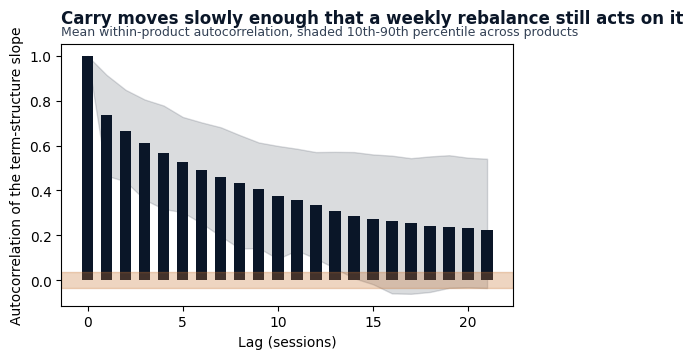

In [8]:
sealed = pl.col("session_date") < pl.lit(HOLDOUT_START).str.to_date()
term = (
    futures.filter((pl.col("tenor") <= 1) & sealed)
    .pivot(on="tenor", index=["product", "session_date"], values="raw_close")
    .rename({"0": "near", "1": "deferred"})
    .drop_nulls()
    .sort(["product", "session_date"])
    .with_columns(((pl.col("deferred") - pl.col("near")) / pl.col("near")).alias("slope"))
)
acf = panel_acf(term, entity_col="product", value_col="slope", max_lags=max(HORIZONS))

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.fill_between(acf["lag"], acf["acf_p10"], acf["acf_p90"], color=COLORS["blue"], alpha=0.15)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.6)
ax.axhspan(-acf["band"][0], acf["band"][0], color=COLORS["copper"], alpha=0.3)
ax.set_xlabel("Lag (sessions)")
ax.set_ylabel("Autocorrelation of the term-structure slope")
add_message_title(
    ax,
    "Carry moves slowly enough that a weekly rebalance still acts on it",
    subtitle="Mean within-product autocorrelation, shaded 10th-90th percentile across products",
)
plt.show()

### B.5 Move scale against cost

The ratio below divides the median absolute move at the primary label horizon by the
round-trip spread. It is a scale comparison: the numerator is a realised move rather
than a forecast, so a large ratio says cost is not the binding constraint and nothing
about whether the sign is predictable.

In [9]:
median_move_bps = float(returns[f"h{HORIZONS[0]}"].drop_nulls().median() * 10_000)
clears_cost = float((returns[f"h{HORIZONS[0]}"].drop_nulls() > COST_FRACTION).mean())
print(
    f"Round-trip spread {cost['round_trip_bps'].min():.2f} to "
    f"{cost['round_trip_bps'].max():.2f} bps, median {COST_BPS:.2f} bps"
)
print(
    f"Median {HORIZONS[0]}-session move {median_move_bps:.1f} bps, "
    f"ratio {median_move_bps / COST_BPS:.0f}x, share above spread {clears_cost:.3f}"
)

Round-trip spread 0.36 to 5.78 bps, median 1.01 bps
Median 5-session move 121.2 bps, ratio 120x, share above spread 0.991


The median round-trip spread across the thirty products is 1.01 bps, from 0.36 bps on
the two-year note to 5.78 bps on corn. The median absolute five-session move is 121.2
bps, and 0.991 of five-session moves exceed the spread they would have to cross.

## C. Design decisions

### C.1 Cadence

`setup.yaml::decision.cadence` rebalances at the Friday settlement and executes at the
Monday open. B.3 supports that from the cost side: moves at both horizons sit far above
the spread, so the signal sets the cadence rather than cost. Roll yield accrues whether
or not the book turns over, so a faster cadence pays more spread for the same carry.

### C.2 Kill conditions

Three thresholds would send the strategy back to the drawing board, declared here and
tested where the evidence exists rather than in this notebook: a combined
carry-and-momentum information coefficient below its floor across folds; long-
backwardation carry turning profitable over the full sample, which would make an
inverted-carry reading a regime artifact; and round-trip cost above the median
absolute move for most of the universe, which the cost stage re-tests in full.

### C.3 Mapping class

`setup.yaml::mapping.class` ranks products by carry or momentum and holds both legs.
Shorting a future carries no borrow, so the short leg costs what the long leg costs.
Sizing is equal-risk rather than equal-notional because volatilities across the
universe differ by an order of magnitude, and notional weighting would hand the book
to energy and grains. A quintile of thirty products holds six, which is the real limit
on a rank signal's power here.

## D. Walk-forward structure

### D.1 Effective sample size

What evaluation spends is decision dates, not rows: one per week per product here.

In [10]:
n_weeks = research.select(pl.col("session_date").dt.truncate("1w").n_unique()).item()
print(
    f"Sessions {research['session_date'].n_unique():,} | decision dates {n_weeks:,} "
    f"| rows per decision date {len(research) / n_weeks:.0f}"
)

Sessions 3,357 | decision dates 678 | rows per decision date 145


### D.2 Fold demonstration

`generate_cv_splits` derives the folds from `setup.yaml::evaluation` alone, so the
boundaries are the declared design rather than a copy of it. Between each training
block and its validation block sits a purge gap the width of the label horizon, which
stops a label computed inside training from resolving inside validation.

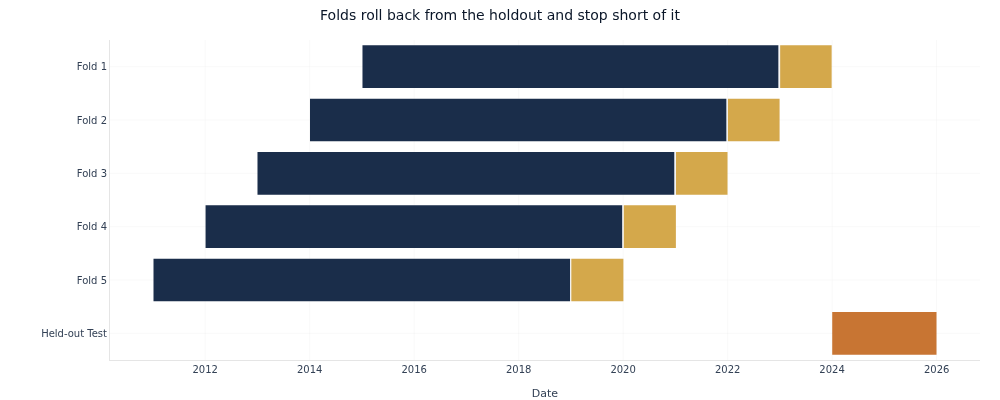

In [11]:
splits = generate_cv_splits(
    research.select("session_date").rename({"session_date": "timestamp"}),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    date_col="timestamp",
)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert max(s["val_end"] for s in splits) < np.datetime64(HOLDOUT_START), "fold hits holdout"

cv = WalkForwardCV(config=make_walk_forward_config(CASE_STUDY_ID, label_horizon=LABEL_BUFFER))
cv.expanding = False
timeline = front.select(
    pl.col("session_date").cast(pl.Datetime("us", "UTC")).unique().sort().alias("timestamp")
)
fold_timeline(cv, timeline, title="Folds roll back from the holdout and stop short of it").show()

## E. Derived artifacts

This notebook writes nothing: the exchange's listings fix the universe, so there is no
point-in-time eligibility file for a later stage to read.

## F. Findings vs `setup.yaml`

One row per knob: the evidence that motivates it, and what a reader would have to see
on their own data to set it differently.

| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.n_products` | B.2 breadth per decision date | breadth falls below the position count the sweep asks for on either leg |
| `decision.cadence` | B.3 exceedance, B.4 persistence | moves stop clearing the spread, or the slope decays inside one rebalancing interval |
| `labels.primary` | B.3 exceedance at each horizon | a longer horizon separates moves from cost by a wider margin than the shorter one |
| `evaluation.n_splits` | D.1 decision dates, D.2 boundaries | the folds no longer fit the development window, or validation reaches the holdout |

In [12]:
print(
    f"universe.n_products {SETUP['universe']['n_products']}, breadth per decision date "
    f"{breadth['n_products'].min()} to {breadth['n_products'].max()}"
)
print(f"decision.cadence {SETUP['decision']['cadence']} | labels.primary {PRIMARY_LABEL}")
print(
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, last "
    f"validation ends {max(s['val_end'] for s in splits).date()}, holdout untouched"
)

universe.n_products 30, breadth per decision date 26 to 30
decision.cadence weekly_friday_close | labels.primary fwd_ret_5d
evaluation.n_splits 5, generated 5, last validation ends 2023-12-21, holdout untouched


Breadth runs from 26 to 30 products per weekly decision date, so the floor of 20
never binds. Five folds are generated from the declared design, and the last
validation block ends 2023-12-21, ten days before the holdout opens.

## Key takeaways

1. **Count the universe at every decision date.** A mean breadth hides the dates where
   a two-sided book cannot be filled, and those cluster early in the sample.
2. **Recover cost from the price grid where the vendor quotes none.** The smallest
   non-zero settlement increment is the tick, and one tick is what a round trip across
   a one-tick spread costs, per product rather than as a single assumption.
3. **Compare moves to cost with an exceedance curve rather than a histogram.** One
   shared logarithmic axis puts every candidate horizon in the same picture.
4. **Autocorrelation on a panel is computed inside each entity.** Stacking entities and
   correlating the result measures the joins between them.
5. **Seal the holdout before the first statistic, not the first model.** A cadence or a
   cost threshold read off the holdout leaks like a fitted parameter.

### Known limitations

- The recovered tick understates cost where the exchange settles on half-ticks, and
  excludes the commission and roll slippage `setup.yaml::costs` also declares.
- A persistent carry reading is not a profitable one. Whether the slope predicts the
  sign of the next move is what the modelling stages test.

**Next**: labels at the declared horizons, built on this development window.